In [31]:
import pandas as pd
import numpy as np

In [32]:
df = pd.read_excel("Exploratory Data Analysis.xlsx",sheet_name="Raw_Data")
df_clean = pd.read_excel('Exploratory Data Analysis.xlsx',sheet_name="Cleaned_Data")

In [33]:
df.tail()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice,Duplicate_Check,Missing_Check,Date_Check,Precision_Check
1198,ORD201198,2024-08-22,C64753,Chair,4.0,262.52,509 Main St,Debit Card,Cancelled,TRK71683331,4.0,WINTER15,Instagram,1050.08,Unique,OK,OK,OK
1199,ORD201199,2023-06-11,C57502,Tablet,4.0,560.58,201 Main St,Gift Card,Returned,TRK51116746,6.0,SAVE10,Referral,2242.32,Unique,OK,OK,OK
1200,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1201,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,TOTAL ISSUES FOUND:,309,NaN,NaN,NaN
1202,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,STATUS:,NEEDS REVIEW,NaN,NaN,NaN


In [34]:
df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice,Duplicate_Check,Missing_Check,Date_Check,Precision_Check
0,ORD200000,2023-01-04,C72649,Monitor,5.0,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7.0,SAVE10,Instagram,2853.1,Unique,OK,OK,OK
1,ORD200001,2024-08-23,C75739,Phone,2.0,151.35,823 Main St,Online,Shipped,TRK91186779,3.0,SAVE10,Referral,302.7,Unique,OK,OK,OK
2,ORD200002,2024-02-27,C81728,Tablet,5.0,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8.0,FREESHIP,Email,2753.4,Unique,OK,OK,OK
3,ORD200003,2023-10-15,C33540,Chair,1.0,273.19,275 Main St,Debit Card,Returned,TRK62788070,5.0,SAVE10,Facebook,273.19,Unique,OK,OK,OK
4,ORD200004,2025-05-08,C81840,Printer,4.0,626.01,668 Main St,Online,Delivered,TRK29241424,8.0,SAVE10,Email,2504.04,Unique,OK,OK,OK


In [37]:
df = df.loc[:1199,:"TotalPrice"]
df_clean = df_clean.iloc[:1200]

In [38]:
df.shape,df_clean.shape

((1200, 14), (1200, 18))

In [39]:
duplicate_check = df['OrderID'].duplicated().sum()
missing_check = df['CouponCode'].isna().sum()
df['Date'] = pd.to_datetime(df['Date'],errors="coerce") # Incorrect formatted date stores as NaT
date_check = df['Date'].isna().sum()
precision_check = (round(df['UnitPrice'],2) != df["UnitPrice"]).sum()

print(f"Total Number of Issues: {duplicate_check + missing_check + date_check + precision_check}")

Total Number of Issues: 309


In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          1200 non-null   object        
 1   Date             1200 non-null   datetime64[ns]
 2   CustomerID       1200 non-null   object        
 3   Product          1200 non-null   object        
 4   Quantity         1200 non-null   float64       
 5   UnitPrice        1200 non-null   float64       
 6   ShippingAddress  1200 non-null   object        
 7   PaymentMethod    1200 non-null   object        
 8   OrderStatus      1200 non-null   object        
 9   TrackingNumber   1200 non-null   object        
 10  ItemsInCart      1200 non-null   float64       
 11  CouponCode       891 non-null    object        
 12  ReferralSource   1200 non-null   object        
 13  TotalPrice       1200 non-null   object        
dtypes: datetime64[ns](1), float64(3), object

In [41]:
df['TotalPrice'] = df['TotalPrice'].astype('float64')

In [42]:
category_col = ['Product','PaymentMethod','OrderStatus']
for x in category_col:
    df[x] = df[x].astype(dtype='category')

In [43]:
df["UnitPrice"].isna().sum()

np.int64(0)

In [61]:
df["UnitPrice"] = df['UnitPrice'].astype(dtype='int64')

In [62]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          1200 non-null   object        
 1   Date             1200 non-null   datetime64[ns]
 2   CustomerID       1200 non-null   object        
 3   Product          1200 non-null   category      
 4   Quantity         1200 non-null   float64       
 5   UnitPrice        1200 non-null   int64         
 6   ShippingAddress  1200 non-null   object        
 7   PaymentMethod    1200 non-null   category      
 8   OrderStatus      1200 non-null   category      
 9   TrackingNumber   1200 non-null   object        
 10  ItemsInCart      1200 non-null   float64       
 11  CouponCode       1200 non-null   object        
 12  ReferralSource   1200 non-null   object        
 13  TotalPrice       1200 non-null   float64       
dtypes: category(3), datetime64[ns](1), float

In [46]:
df.duplicated().sum() # No duplicated rows exist

np.int64(0)

In [47]:
df.isna().sum()

OrderID              0
Date                 0
CustomerID           0
Product              0
Quantity             0
UnitPrice            0
ShippingAddress      0
PaymentMethod        0
OrderStatus          0
TrackingNumber       0
ItemsInCart          0
CouponCode         309
ReferralSource       0
TotalPrice           0
dtype: int64

In [48]:
df['CouponCode'].value_counts(dropna=False)


CouponCode
FREESHIP    313
NaN         309
WINTER15    292
SAVE10      286
Name: count, dtype: int64

In [49]:
df['CouponCode'] = df['CouponCode'].fillna("No Coupon")
df['CouponCode'].value_counts(dropna=False)

CouponCode
FREESHIP     313
No Coupon    309
WINTER15     292
SAVE10       286
Name: count, dtype: int64

In [50]:
df.describe()

,Date,Quantity,UnitPrice,ItemsInCart,TotalPrice
count,1200,1200.000000,1200.000000,1200.000000,1200.000000
mean,2024-03-22 16:58:48,2.945833,356.412750,5.485000,1053.968300
min,2023-01-01 00:00:00,1.000000,11.390000,1.000000,11.390000
25%,2023-08-03 18:00:00,2.000000,186.062500,4.000000,410.520000
50%,2024-03-23 00:00:00,3.000000,364.210000,5.000000,823.615000
75%,2024-11-08 12:00:00,4.000000,521.570000,7.000000,1578.475000
max,2025-06-30 00:00:00,5.000000,699.930000,10.000000,3456.400000
std,NaN,1.407557,197.177146,2.281983,819.856558


In [51]:
import seaborn as sns
import matplotlib.pyplot as plt

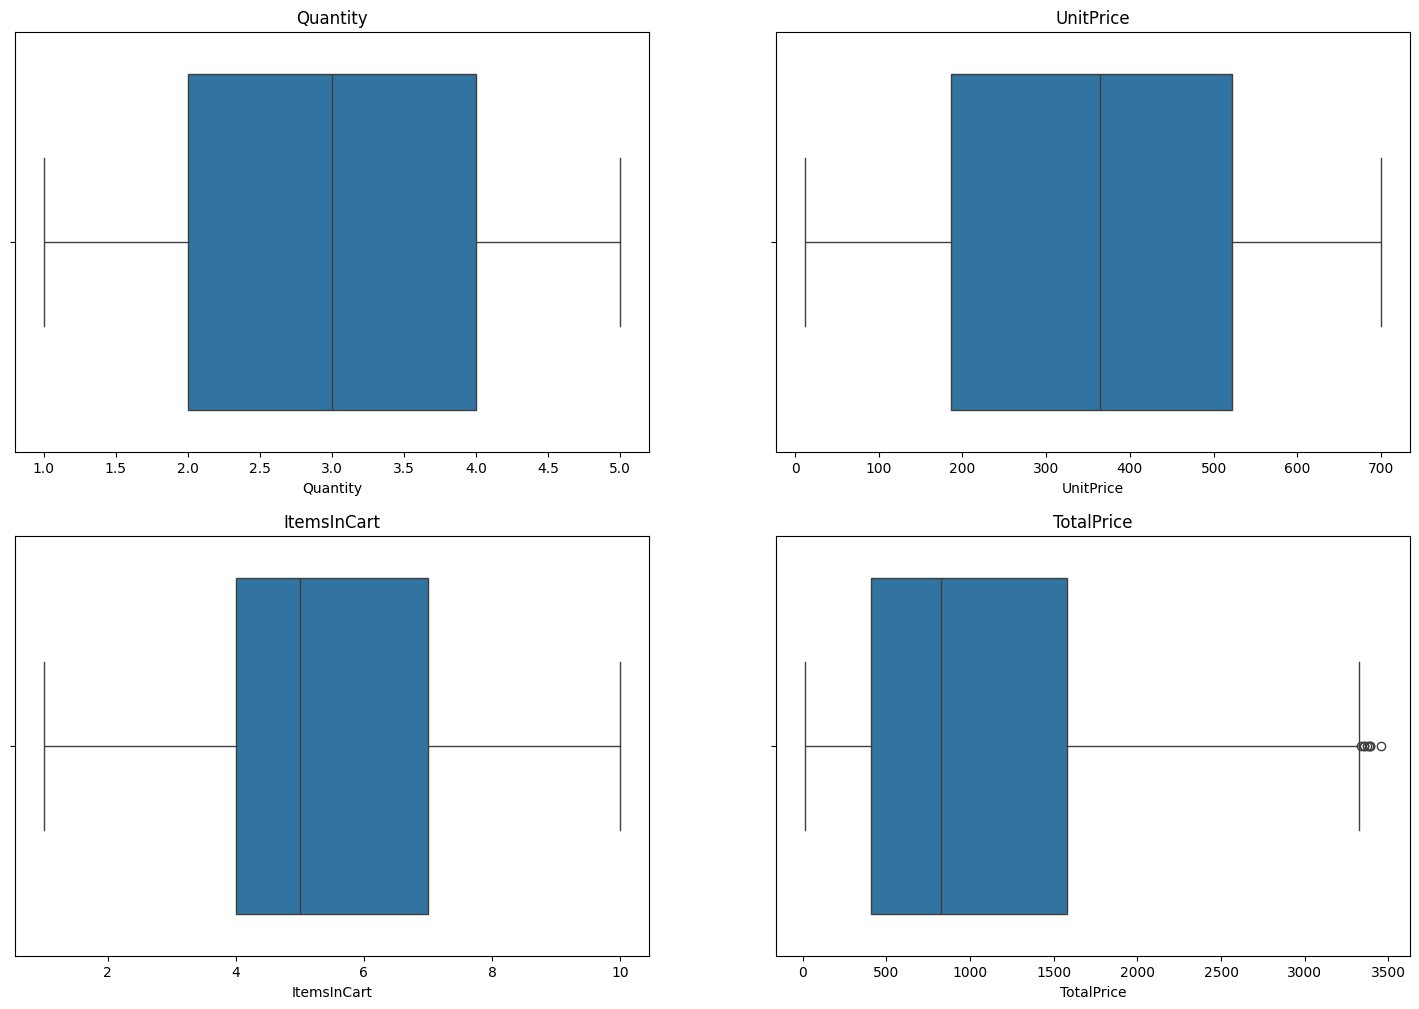

In [52]:
num_cols = df.select_dtypes(include=['float64']).columns

fig = plt.figure(figsize=(18,12))
for i in range(len(num_cols)):
    ax = fig.add_subplot(2,2,i+1)
    sns.boxplot(x = df[num_cols[i]],ax=ax)
    ax.set_title(num_cols[i])
plt.show()
# TotalPrice has outlier values

In [53]:
q1 = df['TotalPrice'].quantile(0.25)
q3 = df['TotalPrice'].quantile(0.75)
IQR = q3 - q1
upper_limit = q3 + 1.5 * IQR
lower_limit = q1 - 1.5 * IQR

outlier_count = (df['TotalPrice'] > upper_limit).sum()
print(f"Total outlier in TotalPrice column: {outlier_count}")

Total outlier in TotalPrice column: 8


In [54]:
df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5.0,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7.0,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2.0,151.35,823 Main St,Online,Shipped,TRK91186779,3.0,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5.0,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8.0,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1.0,273.19,275 Main St,Debit Card,Returned,TRK62788070,5.0,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4.0,626.01,668 Main St,Online,Delivered,TRK29241424,8.0,SAVE10,Email,2504.04


In [58]:
df["Product"].value_counts()

Product
Printer    181
Tablet     179
Chair      178
Laptop     173
Desk       170
Monitor    163
Phone      156
Name: count, dtype: int64

In [59]:
df['PaymentMethod'].value_counts()

PaymentMethod
Online         258
Cash           246
Credit Card    234
Debit Card     232
Gift Card      230
Name: count, dtype: int64

In [60]:
df['OrderStatus'].value_counts()

OrderStatus
Cancelled    250
Returned     247
Pending      237
Shipped      235
Delivered    231
Name: count, dtype: int64

# Analysis Done